In [5]:
from pathlib import Path
import io

import pandas as pd
from tqdm.auto import tqdm

from google.colab import auth
auth.authenticate_user()

from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload

drive_service = build("drive", "v3")

# Paste the Data folder ID printed by the previous upload script
DATA_FOLDER_ID = "15o0Cq15Uqy_oeWQ9egCcKVv2fi6W5Iu9"

LOCAL_DATA_DIR = Path("/content/data")
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

filenames = [
    "listings.csv.gz",
    "calendar.csv.gz",
    "reviews.csv.gz",
    "listings_summary.csv",
    "mvv_train_stations.csv",
]


def find_file_in_folder(filename: str, folder_id: str) -> str:
    query = (
        f"name = '{filename}' "
        f"and '{folder_id}' in parents "
        f"and trashed = false"
    )

    results = drive_service.files().list(
        q=query,
        fields="files(id, name, size)",
        supportsAllDrives=True,
        includeItemsFromAllDrives=True,
    ).execute()

    files = results.get("files", [])

    if not files:
        raise FileNotFoundError(f"Could not find {filename} in Drive data folder.")

    return files[0]["id"]


def download_drive_file(file_id: str, local_path: Path):
    request = drive_service.files().get_media(
        fileId=file_id,
        supportsAllDrives=True,
    )

    with open(local_path, "wb") as f:
        downloader = MediaIoBaseDownload(f, request)

        done = False
        with tqdm(unit="B", unit_scale=True, desc=local_path.name) as progress:
            previous_bytes = 0

            while not done:
                status, done = downloader.next_chunk()

                if status:
                    current_bytes = int(status.resumable_progress)
                    progress.update(current_bytes - previous_bytes)
                    previous_bytes = current_bytes


# Download files from Google Drive/data to local Colab runtime
for filename in filenames:
    local_path = LOCAL_DATA_DIR / filename

    if local_path.exists():
        print(f"Skipping {filename}, already downloaded locally.")
        continue

    print(f"Finding {filename} in Drive...")
    file_id = find_file_in_folder(filename, DATA_FOLDER_ID)

    print(f"Downloading {filename} to {local_path}...")
    download_drive_file(file_id, local_path)

print("\nFiles available locally in:")
print(LOCAL_DATA_DIR)

Finding listings.csv.gz in Drive...


listings.csv.gz: 0.00B [00:00, ?B/s]

Finding calendar.csv.gz in Drive...


calendar.csv.gz: 0.00B [00:00, ?B/s]

Finding reviews.csv.gz in Drive...


...

Finding listings_summary.csv in Drive...


listings_summary.csv: 0.00B [00:00, ?B/s]

Finding mvv_train_stations.csv in Drive...


mvv_train_stations.csv: 0.00B [00:00, ?B/s]


Files available locally in:
/content/data


In [6]:
!ls "data"

calendar.csv.gz  listings_summary.csv	 reviews.csv.gz
listings.csv.gz  mvv_train_stations.csv


In [7]:
summary_data = pd.read_csv("data/listings_summary.csv")
full_data = pd.read_csv("data/listings.csv.gz")
stations_data = pd.read_csv(
    "data/mvv_train_stations.csv",
    sep=";",          # German CSVs often use semicolon
    decimal=",",      # German decimal separator
    encoding="utf-8",
)

print("Summary data shape: ", summary_data.shape)
print("Full data shape: ", full_data.shape)
print("MVV data shape: ", stations_data.shape)

Summary data shape:  (8274, 18)
Full data shape:  (8274, 79)
MVV data shape:  (11061, 6)


/tmp/ipykernel_1585/1716380484.py:2: DtypeWarning: Columns (72) have mixed types. Specify dtype option on import or set low_memory=False.
  full_data = pd.read_csv("data/listings.csv.gz")


In [8]:
print(summary_data.columns)
print(full_data.columns)

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license'],
      dtype='object')
Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', '

In [41]:
full_data[['number_of_reviews', 'price', 'host_response_rate']]
full_data['host_response_rate'].min()

TypeError: '<=' not supported between instances of 'float' and 'str'

In [20]:
row = summary_data.loc[summary_data['number_of_reviews'].idxmax()]
row

,1351
id,30363681
name,"Double Room, Downtown Vi Vadi Hotel"
host_id,219447456
host_name,Clemens Peter
neighbourhood_group,NaN
neighbourhood,Maxvorstadt
latitude,48.14321
longitude,11.55895
room_type,Hotel room
price,306.0


In [ ]:
relevant_columns = ['id',
 'name',
 'description',
 'neighborhood_overview',
 'host_since',
 'host_response_time',
 'host_response_rate',
 'latitude',
 'longitude',
 'bathrooms',
 'bedrooms',
 'beds',
 'price',
 'minimum_nights',
 'maximum_nights',
]

df = full_data[relevant_columns]
df = df[df["price"].notna()]
df.head(5)



,id,name,description,neighborhood_overview,host_since,host_response_time,host_response_rate,latitude,longitude,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights
0,97945,Deluxw-Apartm. with roof terrace,NaN,We are living in a outskirt of Munich its call...,2011-04-18,NaN,NaN,48.11492,11.48954,1.0,1.0,1.0,$105.00,2,90
2,127383,City apartment next to Pinakothek,NaN,NaN,2011-05-26,within a few hours,100%,48.15199,11.56482,1.0,1.0,1.0,$288.00,3,20
4,170154,"Own floor & bath, parking & breakfast","Enjoy a quiet neighbourhood, easy access to th...",NaN,2010-04-14,within a few hours,100%,48.10814,11.52733,1.0,1.0,2.0,$142.00,3,1125
6,172977,Beautiful room close to centre,NaN,You will find in a very close walking distance...,2011-07-16,within a day,80%,48.14957,11.55507,1.0,1.0,1.0,$120.00,2,7
7,187359,Charming apartment near City Center,My apartment is located in the heart of Munich...,The best bakers of Munich are right next door....,2011-08-01,NaN,NaN,48.15638,11.53935,1.0,1.0,1.0,$68.00,2,35


In [ ]:
print(df.dtypes)
price_objects_df = df["price"]
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
print("--- After ---")
print(df.dtypes)

id                         int64
name                      object
description               object
neighborhood_overview     object
host_since                object
host_response_time        object
host_response_rate        object
latitude                 float64
longitude                float64
bathrooms                float64
bedrooms                 float64
beds                     float64
price                     object
minimum_nights             int64
maximum_nights             int64
dtype: object
--- After ---
id                         int64
name                      object
description               object
neighborhood_overview     object
host_since                object
host_response_time        object
host_response_rate        object
latitude                 float64
longitude                float64
bathrooms                float64
bedrooms                 float64
beds                     float64
price                    float64
minimum_nights             int64
maximum_nights 

In [ ]:
df[df["bathrooms"] > 1].head(5)

,id,name,description,neighborhood_overview,host_since,host_response_time,host_response_rate,latitude,longitude,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights
8,189551,Spacious Loft with Rooftop Terrace in City Center,NaN,The district is located in the western city ce...,2011-08-03,within an hour,100%,48.135919,11.544271,1.5,2.0,4.0,830.0,1,1125
30,199843,Exclusive and trendy 3-room apartment,"Modern, exclusive and trendy furnished 3-room ...",Maxvorstadt is one of the most exclusive and a...,2011-08-16,within a day,100%,48.150540,11.575910,2.0,2.0,2.0,237.0,30,730
46,210348,one quiet nice room in a condo in central munich,"i am offering a room with a french bed, sunny...",the river isar is close where people relax and...,2011-08-30,within an hour,83%,48.124010,11.561190,1.5,1.0,1.0,133.0,2,14
52,217313,Munich City Big House+garden near Westpark,House+garden for 6 or 7 persons!<br />Many pub...,The Westpark is beautifull.There are many <br ...,2011-09-07,within a few hours,100%,48.127350,11.513180,3.0,5.0,7.0,855.0,5,21
56,223439,Private Room in Munich City Center,NaN,NaN,2011-08-30,within an hour,100%,48.128940,11.563840,1.5,7.0,0.0,343.0,1,3


In [ ]:
mask = df["bathrooms"] == df["bathrooms"].max()
df[mask].head(5)

,id,name,description,neighborhood_overview,host_since,host_response_time,host_response_rate,latitude,longitude,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights
5684,1233944172655839683,Oktoberfest All-Inclusive Camping,Our accommodation and party package includes a...,NaN,2018-03-02,within an hour,92%,48.174499,11.448862,8.0,50.0,2.0,119.0,1,365


In [ ]:
stations_data.head(5)
print(stations_data.dtypes)

HstNummer          int64
Name ohne Ort     object
Ort               object
Globale ID        object
WGS84 X          float64
WGS84 Y          float64
dtype: object


In [ ]:
stations_data.head(5)


,HstNummer,Name ohne Ort,Ort,Globale ID,WGS84 X,WGS84 Y
0,1,Karlsplatz (Stachus),München,de:09162:1,48.139367,11.565396
1,2,Marienplatz,München,de:09162:2,48.136436,11.577658
2,3,Isartor,München,de:09162:3,48.133894,11.582823
3,4,Rosenheimer Platz,München,de:09162:4,48.128588,11.593900
4,5,Ostbahnhof,München,de:09162:5,48.128138,11.604069


In [ ]:
print(df["latitude"].isna().any())
print(df["longitude"].isna().any())
print(df[["latitude", "longitude"]].eq(0).any())

False
False
latitude     False
longitude    False
dtype: bool


In [ ]:
price_list = df["price"].sort_values(ascending=False)
top20 = price_list.nlargest(20).index
price_objects_df.loc[top20]

,price
1140,"$11,303.00"
6887,"$9,572.00"
6597,"$9,572.00"
6888,"$9,572.00"
7254,"$9,143.00"
5232,"$9,143.00"
5231,"$9,143.00"
7324,"$9,143.00"
3639,"$6,858.00"
5709,"$3,386.00"


In [ ]:
p99 = df["price"].quantile(0.998)
print(p99)
df_p99 = df[df["price"] <= p99]
df_p99["price"].sort_values(ascending=False).head(20)

2405.0880000000216


,price
6965,2343.0
3893,2306.0
7140,2204.0
7512,2186.0
3768,2043.0
8104,2025.0
6129,2000.0
3973,1993.0
1493,1906.0
7723,1858.0


In [ ]:
df["price"].sort_values().head(20)


,price
6047,15.0
6700,16.0
51,26.0
6496,27.0
4696,27.0
467,27.0
7200,28.0
2137,29.0
103,29.0
6875,29.0


In [ ]:
df_p99["price"].sort_values().head(20)

,price
6047,15.0
6700,16.0
51,26.0
6496,27.0
4696,27.0
467,27.0
7200,28.0
2137,29.0
103,29.0
6875,29.0


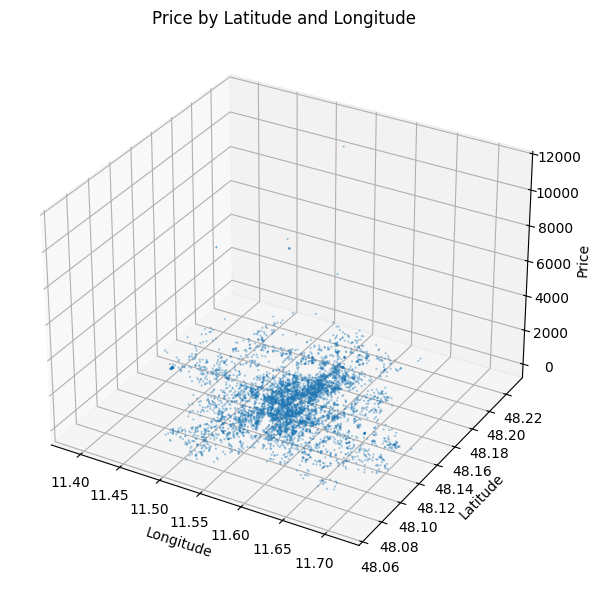

In [ ]:
import matplotlib.pyplot as plt

# 3D plot first
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    df["longitude"],
    df["latitude"],
    df["price"],
    s=0.3,
    alpha=0.4
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Price")
ax.set_title("Price by Latitude and Longitude")

plt.tight_layout()
plt.show()